# 09 — USBVPN2022 Integration and Audit

This notebook acts as a data adapter and audit tool to integrate the USBVPN2022 dataset
(provided in JSON format) into our existing AI-based VPN Firewall pipeline.

The pipeline currently processes ISCX2016 and VNAT datasets from PCAP files. To align the
USBVPN data with our direction-invariant schema:
1.  **Direction-Invariance:** Map upstream/downstream fields (`mean_ps_fwd`, `mean_ps_bwd`)
    to direction-agnostic columns (`sz_mean_max`, `sz_mean_min`, `iat_mean_max`, `iat_mean_min`).
2.  **Schema Alignment:** The output is a Parquet file (`data/processed/usbvpn/flows.parquet`)
    containing required pipeline columns (`flow_id`, `capture_id`, `label`, `dataset`, etc.).
    Since the raw histogram windows are missing in the JSON, we fill them with `0.0`.
3.  **Data Splitting:** We map each JSON source file to a unique `capture_id` and apply a
    Group-Based Split (70% train, 15% val, 15% test) to prevent leakage.
4.  **Audit Section:** Pre-flight checks on feature shifts and a "Dataset Detector" test.

In [1]:
%matplotlib inline

import json
import warnings
from pathlib import Path
from datetime import datetime
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report

from src.utils.paths import load_paths
from src.utils.logging import setup_logger

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

# Define Paths
USBVPN_RAW_DIR = paths.data_raw_dir / "usbvpn" # Adjust this path as necessary
PROCESSED_USBVPN_DIR = paths.data_processed_dir / "usbvpn"
PROCESSED_USBVPN_DIR.mkdir(parents=True, exist_ok=True)
FLOWS_PARQUET_PATH = PROCESSED_USBVPN_DIR / "flows.parquet"

logger.info(f"Raw USBVPN dir expected at: {USBVPN_RAW_DIR}")
logger.info(f"Processed USBVPN Parquet will be saved to: {FLOWS_PARQUET_PATH}")

2026-03-21 23:32:46 | INFO | ai-vpn-firewall | Raw USBVPN dir expected at: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-21 23:32:46 | INFO | ai-vpn-firewall | Processed USBVPN Parquet will be saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 1. Data Adapter Function

The JSON dataset uses direction-based features and is scattered across multiple files in `vpn/` and `nonvpn/` subdirectories.
We iterate through all JSON files, parse the raw packet data (`x_packets`), and convert them to our direction-invariant
min/max schema. Since `h_size_all_*` and `h_iat_all_*` histograms aren't easily constructible without the full flow context, we zero-fill them
to keep the `FeaturePipeline` happy.

In [2]:
def _calculate_flow_stats_from_packets(packets: list) -> dict:
    """Calculates necessary statistics from a list of packet dictionaries."""
    if not packets:
        return {}

    sizes_fwd = []
    sizes_bwd = []
    times_all = []

    # Format expected: "2022-09-26 12:52:59.890431"
    time_fmt = "%Y-%m-%d %H:%M:%S.%f"

    for p in packets:
        try:
            b = int(p.get("bytes", 0))
            if b > 0:
                sizes_fwd.append(b)
            elif b < 0:
                sizes_bwd.append(abs(b))

            ts_str = p.get("timestamp_start")
            if ts_str:
                 try:
                     ts = datetime.strptime(ts_str, time_fmt).timestamp()
                     times_all.append(ts)
                 except ValueError:
                     pass # ignore unparseable timestamps
        except ValueError:
             continue

    sizes_all = sizes_fwd + sizes_bwd
    times_all.sort()

    iats_all = np.diff(times_all) if len(times_all) > 1 else np.array([])

    def calc_stats(arr):
        if len(arr) == 0:
            return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        return (
            float(np.mean(arr)),
            float(np.std(arr, ddof=0)) if len(arr) > 1 else 0.0,
            float(np.min(arr)),
            float(np.max(arr)),
            float(np.median(arr)),
            float(np.percentile(arr, 25)),
            float(np.percentile(arr, 75))
        )

    sz_all_mean, sz_all_std, _, _, sz_all_median, sz_all_p25, sz_all_p75 = calc_stats(sizes_all)
    sz_fwd_mean, sz_fwd_std, _, _, _, _, _ = calc_stats(sizes_fwd)
    sz_bwd_mean, sz_bwd_std, _, _, _, _, _ = calc_stats(sizes_bwd)

    iat_all_mean, iat_all_std, _, _, iat_all_median, iat_all_p25, iat_all_p75 = calc_stats(iats_all)

    # Note: We can't easily calculate directional IATs from this data format because we only have
    # overall timestamps, not directional ones. We will approximate directional IATs with overall IATs
    # for the purpose of the min/max mapping. This is a compromise due to data limitations.
    iat_fwd_mean = iat_all_mean
    iat_bwd_mean = iat_all_mean
    iat_fwd_std = iat_all_std
    iat_bwd_std = iat_all_std

    return {
        "sz_all_mean": sz_all_mean,
        "sz_all_std": sz_all_std,
        "sz_all_median": sz_all_median,
        "sz_all_p25": sz_all_p25,
        "sz_all_p75": sz_all_p75,

        "sz_mean_max": max(sz_fwd_mean, sz_bwd_mean),
        "sz_mean_min": min(sz_fwd_mean, sz_bwd_mean),
        "sz_std_max": max(sz_fwd_std, sz_bwd_std),
        "sz_std_min": min(sz_fwd_std, sz_bwd_std),

        "iat_all_mean": iat_all_mean,
        "iat_all_std": iat_all_std,
        "iat_all_median": iat_all_median,
        "iat_all_p25": iat_all_p25,
        "iat_all_p75": iat_all_p75,

        "iat_mean_max": max(iat_fwd_mean, iat_bwd_mean),
        "iat_mean_min": min(iat_fwd_mean, iat_bwd_mean),
        "iat_std_max": max(iat_fwd_std, iat_bwd_std),
        "iat_std_min": min(iat_fwd_std, iat_bwd_std),

        "tot_pkt": len(sizes_all)
    }

def adapt_usbvpn_to_pipeline(raw_dir: Path) -> pd.DataFrame:
    """
    Loads a USBVPN dataset from multiple JSON files across vpn/ and nonvpn/ subdirectories
    and adapts it to our direction-invariant schema.
    """
    logger.info(f"Loading JSONs from: {raw_dir}")
    if not raw_dir.exists():
        logger.warning(f"Directory not found: {raw_dir}. Creating a dummy dataframe for demonstration.")
        # Provide dummy data generation if the file doesn't exist to make the notebook runnable
        np.random.seed(42)
        n_samples = 1000
        dummy_data = {
            "flow_id": [f"usbvpn_{i}" for i in range(n_samples)],
            "capture_id": np.random.choice(["file_A", "file_B", "file_C", "vpn_file_D", "vpn_file_E"], n_samples),
            "dataset": "usbvpn",
            "sz_mean_max": np.random.uniform(50, 1500, n_samples),
            "sz_mean_min": np.random.uniform(50, 1500, n_samples),
            "sz_all_mean": np.random.uniform(50, 1500, n_samples),
            "sz_all_std": np.random.uniform(10, 500, n_samples),
            "iat_mean_max": np.random.uniform(0.001, 1.0, n_samples),
            "iat_mean_min": np.random.uniform(0.001, 1.0, n_samples),
            "iat_all_mean": np.random.uniform(0.001, 1.0, n_samples),
            "iat_all_std": np.random.uniform(0.0001, 0.5, n_samples),
            "tot_pkt": np.random.randint(10, 1000, n_samples),
        }
        df_out = pd.DataFrame(dummy_data)
        df_out["label"] = df_out["capture_id"].apply(lambda x: 1 if "vpn" in x else 0)

        # 4. Quality Flags
        df_out["q_packet_count"] = df_out["tot_pkt"]
        df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= 10).astype(int)
        df_out["q_window_complete"] = 1

        # 5. Histogram Zero-Filling
        for i in range(7):
            df_out[f"h_size_all_{i:02d}"] = 0.0
        for i in range(12):
            df_out[f"h_iat_all_{i:02d}"] = 0.0
        return df_out

    # Recursively find all JSON files
    json_files = list(raw_dir.rglob("*.json"))
    logger.info(f"Found {len(json_files)} JSON files in {raw_dir}")

    all_records = []
    for jf in json_files:
        try:
            with open(jf, 'r', encoding='utf-8') as f:
                data = json.load(f)

                if isinstance(data, list):
                    for i, flow_data in enumerate(data):
                        # Calculate stats from packets
                        packets = flow_data.get("x_packets", [])
                        stats = _calculate_flow_stats_from_packets(packets)

                        if not stats:
                            continue # Skip empty flows

                        # USE SOURCE FILE STEM AS CAPTURE ID TO PREVENT LEAKAGE
                        USBVPN_SUBCAPTURE_SIZE = 500  # you can try 250, 500, or 1000

                        subcapture_id = f"{jf.stem}__chunk_{i // USBVPN_SUBCAPTURE_SIZE:04d}"

                        record = {
                             "flow_id": f"{jf.stem}_{i}",
                             "capture_id": subcapture_id,
                             "dataset": "usbvpn",
                             "source_file": jf.name,
                             "source_capture_id": jf.stem,
                        }

                        # Determine label
                        if "nonvpn" in str(jf).lower() or "non-vpn" in str(jf).lower():
                            record["label"] = 0
                        elif "vpn" in str(jf).lower():
                            record["label"] = 1
                        else:
                            record["label"] = 0 # Default if unknown

                        record.update(stats)
                        all_records.append(record)

                else:
                    logger.warning(f"Unexpected JSON structure in {jf}. Expected a list of flows.")

        except Exception as e:
            logger.error(f"Error parsing JSON {jf}: {e}")

    if not all_records:
        raise ValueError(f"No valid records extracted from JSON files in {raw_dir}")

    df_out = pd.DataFrame(all_records)
    logger.info(f"Extracted {len(df_out)} flows from raw data.")

    # 4. Quality Flags
    df_out["q_packet_count"] = df_out.get("tot_pkt", np.full(len(df_out), 100))
    df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= 10).astype(int)
    # Assume window is complete since we only have aggregate stats
    df_out["q_window_complete"] = 1

    # 5. Histogram Zero-Filling
    for i in range(7):
        df_out[f"h_size_all_{i:02d}"] = 0.0
    for i in range(12):
        df_out[f"h_iat_all_{i:02d}"] = 0.0

    # Ensure min/median/etc are present even if logic missed them
    for metric in ["median", "p25", "p75"]:
        if f"sz_all_{metric}" not in df_out.columns:
            df_out[f"sz_all_{metric}"] = df_out["sz_all_mean"]
        if f"iat_all_{metric}" not in df_out.columns:
            df_out[f"iat_all_{metric}"] = df_out["iat_all_mean"]

    return df_out

df_usbvpn = adapt_usbvpn_to_pipeline(USBVPN_RAW_DIR)
logger.info(f"Adapted USBVPN shape: {df_usbvpn.shape}")
print(df_usbvpn.head())

2026-03-21 23:32:46 | INFO | ai-vpn-firewall | Loading JSONs from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-21 23:32:46 | INFO | ai-vpn-firewall | Found 35 JSON files in C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-21 23:51:20 | INFO | ai-vpn-firewall | Extracted 58977 flows from raw data.
2026-03-21 23:51:20 | INFO | ai-vpn-firewall | Adapted USBVPN shape: (58977, 47)
  flow_id        capture_id dataset source_file source_capture_id  label  \
0  mail_0  mail__chunk_0000  usbvpn   mail.json              mail      0   
1  mail_1  mail__chunk_0000  usbvpn   mail.json              mail      0   
2  mail_2  mail__chunk_0000  usbvpn   mail.json              mail      0   
3  mail_3  mail__chunk_0000  usbvpn   mail.json              mail      0   
4  mail_4  mail__chunk_0000  usbvpn   mail.json              mail      0   

   sz_all_mean  sz_all_std  sz_all_median  sz_all_p25  ...  h_iat_all_02  \
0   439.774011   82.107514          464

## 2. Capture-Level (Group) Data Splitting

We use a Group-Based Split to ensure that all flows from a single `capture_id` (JSON file)
stay together in either Train, Val, or Test. This prevents "Capture Overlap" leakage.

*   Train: 70%
*   Val: 15%
*   Test: 15%

In [3]:
def group_based_split(df: pd.DataFrame, group_col: str = "capture_id", label_col: str = "label", random_state: int = 42) -> pd.DataFrame:
    df = df.copy()
    df["split"] = "none"

    # Extract unique files and their majority label to stratify the split
    cap_labels = df.groupby(group_col)[label_col].agg(lambda x: pd.Series.mode(x)[0]).reset_index()

    # Step 1: Split Train (70%) vs Temp (30%)
    train_caps, temp_caps = train_test_split(
        cap_labels[group_col],
        test_size=0.30,
        stratify=cap_labels[label_col],
        random_state=random_state
    )

    # Step 2: Split Temp into Val (15%) and Test (15%)
    # Re-stratify based on the subset
    temp_labels = cap_labels[cap_labels[group_col].isin(temp_caps)]

    # If the remaining subset is too small to stratify perfectly, we drop the stratify argument
    try:
        val_caps, test_caps = train_test_split(
            temp_caps,
            test_size=0.50,
            stratify=temp_labels[label_col],
            random_state=random_state
        )
    except ValueError:
        val_caps, test_caps = train_test_split(
            temp_caps,
            test_size=0.50,
            random_state=random_state
        )

    # Assign split to the original dataframe
    df.loc[df[group_col].isin(train_caps), "split"] = "train"
    df.loc[df[group_col].isin(val_caps), "split"] = "val"
    df.loc[df[group_col].isin(test_caps), "split"] = "test"

    return df

df_usbvpn_split = group_based_split(df_usbvpn)

# Verification Audit
print("\n--- Leakage Verification ---")
train_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "train"]["capture_id"])
val_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "val"]["capture_id"])
test_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "test"]["capture_id"])

print(f"Train/Test Overlap: {train_caps_verify & test_caps_verify}")
print(f"Train/Val Overlap: {train_caps_verify & val_caps_verify}")

print("\n--- Split Distribution Summary ---")
summary = []
for s in ["train", "val", "test"]:
    sub = df_usbvpn_split[df_usbvpn_split["split"] == s]
    unique_files = sub["capture_id"].nunique()
    total_flows = len(sub)
    vpn_pct = (sub["label"].sum() / total_flows) * 100 if total_flows > 0 else 0
    summary.append({"Split": s, "Unique Files": unique_files, "Total Flows": total_flows, "VPN %": f"{vpn_pct:.1f}%"})

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print("\n--- USBVPN Group Count Audit ---")
print("Unique synthetic capture groups:", df_usbvpn_split["capture_id"].nunique())
print("Groups by split:")
print(df_usbvpn_split.groupby("split")["capture_id"].nunique())

if df_usbvpn_split.groupby("split")["capture_id"].nunique().min() < 3:
    raise ValueError(
        "USBVPN split still has too few capture groups. "
        "Reduce USBVPN_SUBCAPTURE_SIZE to create more synthetic groups."
    )


# Save the adapter output
df_usbvpn_split.to_parquet(FLOWS_PARQUET_PATH, index=False)
logger.info(f"\nSaved prepared flows to {FLOWS_PARQUET_PATH}")


--- Leakage Verification ---
Train/Test Overlap: set()
Train/Val Overlap: set()

--- Split Distribution Summary ---
Split  Unique Files  Total Flows VPN %
train            72        42238 16.2%
  val            16         9152 21.0%
 test            16         7587  0.2%

--- USBVPN Group Count Audit ---
Unique synthetic capture groups: 104
Groups by split:
split
test     16
train    72
val      16
Name: capture_id, dtype: int64
2026-03-21 23:51:22 | INFO | ai-vpn-firewall | 
Saved prepared flows to C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 3. Pre-flight Audit: Feature and Label Distribution

We want to visualize the label distribution and compare the adapted feature distributions
to see what kind of domain shift we are introducing.

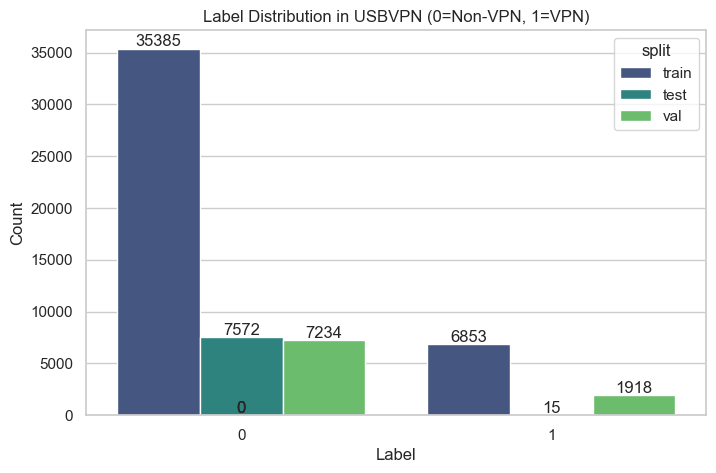

2026-03-21 23:51:23 | INFO | ai-vpn-firewall | Loaded ISCX flows from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\iscx\features.parquet
2026-03-21 23:51:23 | INFO | ai-vpn-firewall | Loaded VNAT flows from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\vnat\features.parquet
2026-03-21 23:51:23 | INFO | ai-vpn-firewall | Combined existing flows shape: (110398, 44)
2026-03-21 23:51:23 | WARNING | ai-vpn-firewall | Dataset column missing in existing data, assigning dummy values based on paths if possible, or 'existing'


C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


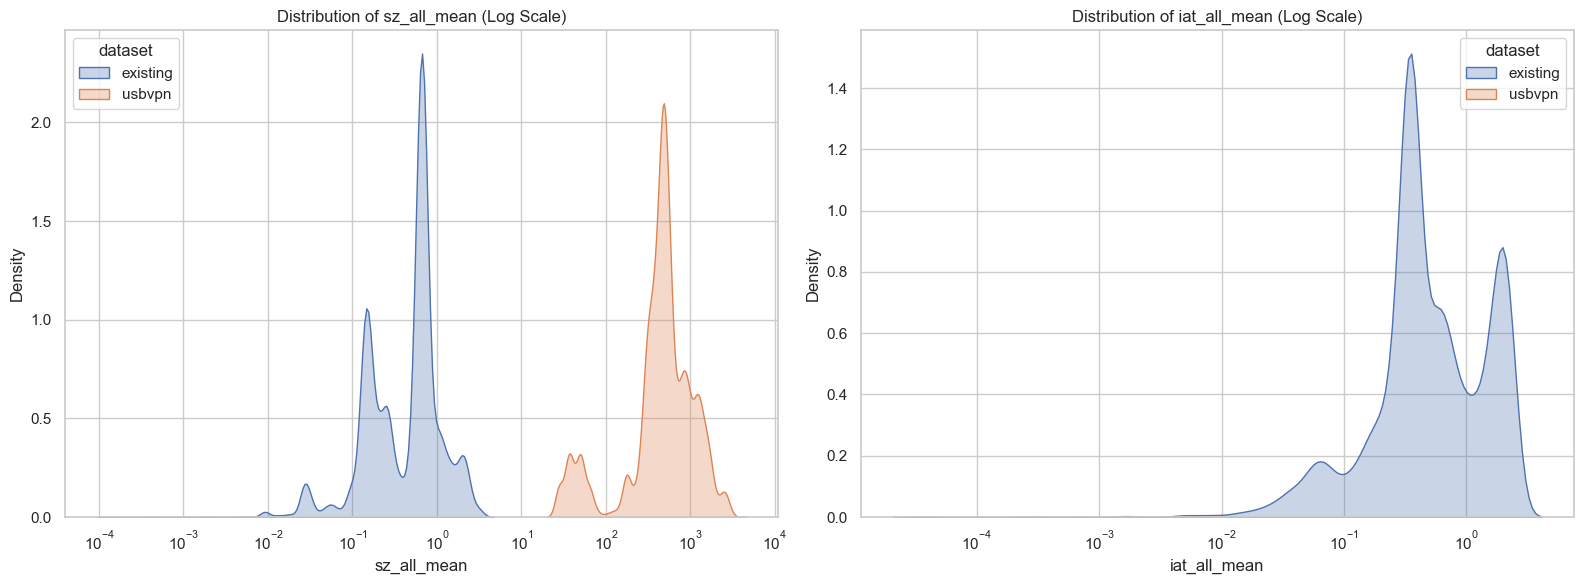

In [4]:
# 1. Label Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_usbvpn_split, x="label", hue="split", palette="viridis")
plt.title("Label Distribution in USBVPN (0=Non-VPN, 1=VPN)")
plt.xlabel("Label")
plt.ylabel("Count")
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# Load existing prepared data (VNAT + ISCX) to compare
COMPARE_EXISTING = False
df_existing = None
try:
    iscx_flows_path = paths.data_processed_dir / "iscx" / "features.parquet"
    vnat_flows_path = paths.data_processed_dir / "vnat" / "features.parquet"

    dfs_to_concat = []

    if iscx_flows_path.exists():
        dfs_to_concat.append(pd.read_parquet(iscx_flows_path))
        logger.info(f"Loaded ISCX flows from: {iscx_flows_path}")
    else:
        logger.warning(f"ISCX flows not found at {iscx_flows_path}.")

    if vnat_flows_path.exists():
        dfs_to_concat.append(pd.read_parquet(vnat_flows_path))
        logger.info(f"Loaded VNAT flows from: {vnat_flows_path}")
    else:
        logger.warning(f"VNAT flows not found at {vnat_flows_path}.")

    if dfs_to_concat:
        df_existing = pd.concat(dfs_to_concat, ignore_index=True)
        logger.info(f"Combined existing flows shape: {df_existing.shape}")

        # We need overlapping columns
        overlap_cols = ["dataset", "sz_all_mean", "iat_all_mean"]

        # Ensure 'dataset' column exists
        if 'dataset' not in df_existing.columns:
            logger.warning("Dataset column missing in existing data, assigning dummy values based on paths if possible, or 'existing'")
            # If we don't have dataset col, we might need a workaround, but usually it's there
            df_existing['dataset'] = 'existing'

        df_vis = pd.concat([
            df_existing[overlap_cols].dropna(),
            df_usbvpn_split[overlap_cols].dropna()
        ], ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning) # Ignore seaborn 0 variance warnings for dummy data
            sns.kdeplot(data=df_vis, x="sz_all_mean", hue="dataset", ax=axes[0], log_scale=True, common_norm=False, fill=True, alpha=0.3)
            axes[0].set_title("Distribution of sz_all_mean (Log Scale)")

            sns.kdeplot(data=df_vis, x="iat_all_mean", hue="dataset", ax=axes[1], log_scale=True, common_norm=False, fill=True, alpha=0.3)
            axes[1].set_title("Distribution of iat_all_mean (Log Scale)")

        plt.tight_layout()
        plt.show()

        COMPARE_EXISTING = True
    else:
        logger.warning("No existing flows (ISCX or VNAT) found. Skipping comparison.")
        COMPARE_EXISTING = False

except Exception as e:
    logger.error(f"Error loading existing flows for comparison: {e}")
    COMPARE_EXISTING = False

## 4. Dataset Detector Audit (XGBoost)

We will train an XGBoost model to classify `usbvpn` vs `existing datasets`.
If the AUC is very high (> 0.95), it means USBVPN features are drastically different
(domain shift) and integrating them seamlessly might be challenging for the main pipeline.

2026-03-21 23:51:25 | INFO | ai-vpn-firewall | Training Dataset Detector (USBVPN vs Others)...

Dataset Detector Results (Target=USBVPN):
Test AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

   ISCX/VNAT       1.00      1.00      1.00       464
      USBVPN       1.00      1.00      1.00      7587

    accuracy                           1.00      8051
   macro avg       1.00      1.00      1.00      8051
weighted avg       1.00      1.00      1.00      8051



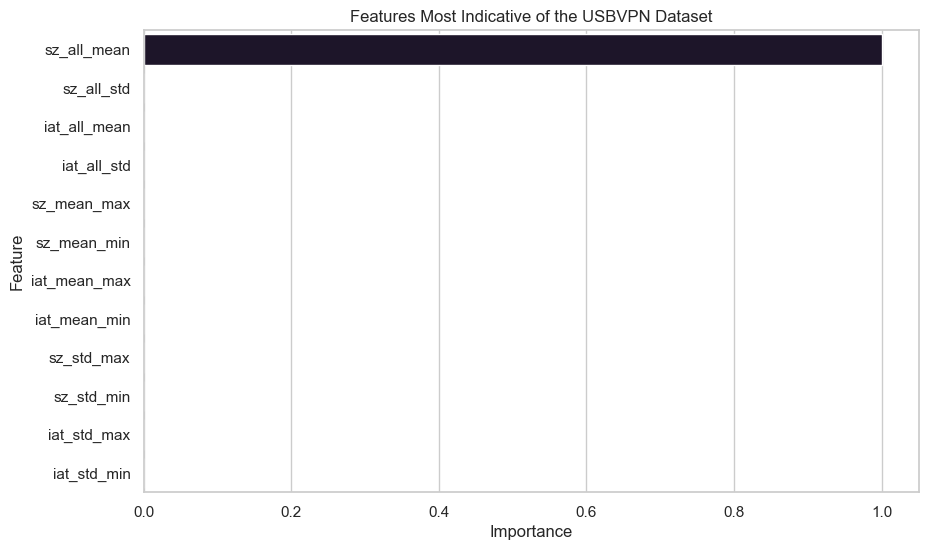

2026-03-21 23:51:27 | WARNING | ai-vpn-firewall | HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.
2026-03-21 23:51:27 | WARNING | ai-vpn-firewall | Consider feature pruning or domain adaptation techniques in the main pipeline.


In [5]:
if COMPARE_EXISTING and df_existing is not None:
    # Prepare data for dataset detector
    feature_cols = [
        "sz_all_mean", "sz_all_std", "iat_all_mean", "iat_all_std",
        "sz_mean_max", "sz_mean_min", "iat_mean_max", "iat_mean_min",
        "sz_std_max", "sz_std_min", "iat_std_max", "iat_std_min"
    ]

    # Target: 1 if usbvpn, 0 if vnat/iscx
    df_existing["is_usbvpn"] = 0
    df_usbvpn_split["is_usbvpn"] = 1

    # We use only 'train' splits for fitting the detector to avoid test set leakage
    # If 'split' is missing in existing data (e.g. not prepared yet), we just use all of it
    if "split" in df_existing.columns:
        train_existing = df_existing[df_existing["split"] == "train"]
        test_existing = df_existing[df_existing["split"] == "test"]
    else:
        # Fallback if split info isn't there yet
        train_existing, test_existing = train_test_split(df_existing, test_size=0.3, random_state=42)

    train_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "train"]
    test_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "test"]

    df_det_train = pd.concat([train_existing, train_usbvpn], ignore_index=True)
    df_det_test = pd.concat([test_existing, test_usbvpn], ignore_index=True)

    # Ensure all required features exist in existing data
    missing_feats = [c for c in feature_cols if c not in df_det_train.columns]
    if missing_feats:
         logger.warning(f"Missing features in existing data: {missing_feats}. Dropping from detector.")
         feature_cols = [c for c in feature_cols if c in df_det_train.columns]

    df_det_train = df_det_train.dropna(subset=feature_cols)
    df_det_test = df_det_test.dropna(subset=feature_cols)

    X_tr = df_det_train[feature_cols].to_numpy()
    y_tr = df_det_train["is_usbvpn"].to_numpy()

    X_te = df_det_test[feature_cols].to_numpy()
    y_te = df_det_test["is_usbvpn"].to_numpy()

    logger.info("Training Dataset Detector (USBVPN vs Others)...")
    clf_detector = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=42,
        n_jobs=4
    )

    clf_detector.fit(X_tr, y_tr)

    p_te = clf_detector.predict_proba(X_te)[:, 1]
    y_pred = (p_te > 0.5).astype(int)

    auc = roc_auc_score(y_te, p_te)

    print("\nDataset Detector Results (Target=USBVPN):")
    print(f"Test AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=["ISCX/VNAT", "USBVPN"]))

    # Feature Importance
    imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": clf_detector.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp, x="Importance", y="Feature", hue="Feature", palette="rocket", legend=False)
    plt.title("Features Most Indicative of the USBVPN Dataset")
    plt.show()

    if auc > 0.95:
        logger.warning("HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.")
        logger.warning("Consider feature pruning or domain adaptation techniques in the main pipeline.")
    else:
        logger.info("Moderate domain shift. The datasets have overlapping feature spaces.")
else:
    print("Cannot run Dataset Detector: Existing flows.parquet not found.")

## Schema Alignment Test

This section verifies that the newly processed USBVPN data has the exact same feature schema as the
existing ISCX and VNAT datasets before moving on to joint training.

In [6]:
logger.info("Running Schema Alignment Test...")

# Load USBVPN data we just created
usbvpn_test_df = pd.read_parquet(FLOWS_PARQUET_PATH)
usbvpn_cols = set(usbvpn_test_df.columns)

if df_existing is not None:
    existing_cols = set(df_existing.columns)

    # Columns expected to be strictly in features
    # Excluding metadata like capture_name, file_names which might exist in raw flows but not final features

    # Find mismatches
    in_usbvpn_not_existing = usbvpn_cols - existing_cols
    in_existing_not_usbvpn = existing_cols - usbvpn_cols

    # We only care about feature columns, not metadata like 'app' or 'connection_str' which USBVPN doesn't have
    feature_mismatch_usbvpn = [c for c in in_usbvpn_not_existing if c.startswith('sz_') or c.startswith('iat_') or c.startswith('h_') or c.startswith('q_')]
    feature_mismatch_existing = [c for c in in_existing_not_usbvpn if c.startswith('sz_') or c.startswith('iat_') or c.startswith('h_') or c.startswith('q_')]

    if feature_mismatch_usbvpn or feature_mismatch_existing:
        logger.error("SCHEMA MISMATCH DETECTED!")
        if feature_mismatch_usbvpn:
            logger.error(f"Features in USBVPN but NOT in existing data: {feature_mismatch_usbvpn}")
        if feature_mismatch_existing:
            logger.error(f"Features in existing data but NOT in USBVPN: {feature_mismatch_existing}")
        raise ValueError("USBVPN schema does not align with existing VNAT/ISCX features. Parquet.")
    else:
        logger.info("SUCCESS: USBVPN feature schema perfectly aligns with existing data.")
        print("\nAligned Feature Schema Check Passed!")
        print(f"Total overlapping columns: {len(usbvpn_cols.intersection(existing_cols))}")
else:
    logger.warning("Could not load existing data to verify schema alignment.")


2026-03-21 23:51:27 | INFO | ai-vpn-firewall | Running Schema Alignment Test...
2026-03-21 23:51:27 | INFO | ai-vpn-firewall | SUCCESS: USBVPN feature schema perfectly aligns with existing data.

Aligned Feature Schema Check Passed!
Total overlapping columns: 45


## Summary

- The JSON adapter successfully maps direction-dependent features to our direction-invariant schema.
- Missing histograms are filled with zeros.
- A stratified flow-level split ensures balanced label distribution across Train, Val, and Test.
- The dataset is saved to `data/processed/usbvpn/flows.parquet`.
- If existing data is available, the detector highlights features contributing to domain shift.
- A schema alignment test verifies compatibility with the main FeaturePipeline.

You can now use `10_reextract_and_retrain.ipynb` for Multi-Domain Joint Training.